# 01 - OSM Data Exploration & H3 Grid Mapping

**DESIGN.md Â§5.1**: *Data Curation - Map Patna via OSMnx into a hexagonal grid (H3).*

This notebook:
1. Downloads the Patna road network using OSMnx
2. Visualises the road graph
3. Generates an H3 hexagonal grid over the city bounding box
4. Queries OSM for infrastructure POIs (hospitals, police stations, proxy safety indicators)
5. Maps POI counts to each H3 cell to create the DNN feature matrix
6. Exports the processed data for downstream training (notebook 02)

In [1]:
# -- Imports ---------------------------------------------
import osmnx as ox
import networkx as nx
import h3
import folium
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon, Point
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print(f"OSMnx version: {ox.__version__}")
print(f"NetworkX version: {nx.__version__}")

OSMnx version: 2.1.0
NetworkX version: 3.6.1


## 1. Download Patna Road Network

We use `osmnx.graph_from_place()` to fetch the **drivable** road network for Patna.
This gives us a `MultiDiGraph` with nodes (intersections) and edges (road segments),
each annotated with OSM metadata (road type, length, name, etc.).

In [2]:
# -- Download the road network ---------------------------
PLACE_NAME = "Patna, Bihar, India"

G = ox.graph_from_place(PLACE_NAME, network_type="drive", simplify=True)
print(f"Nodes: {G.number_of_nodes():,}")
print(f"Edges: {G.number_of_edges():,}")

Nodes: 23,144
Edges: 55,926


In [3]:
# -- Quick stats on the graph ----------------------------
stats = ox.stats.basic_stats(G)
for key in ['n', 'm', 'k_avg', 'edge_length_total', 'edge_length_avg', 'street_length_total']:
    if key in stats:
        print(f"  {key}: {stats[key]:.2f}" if isinstance(stats[key], float) else f"  {key}: {stats[key]}")

  n: 23144
  m: 55926
  k_avg: 4.83
  edge_length_total: 4386835.17
  edge_length_avg: 78.44
  street_length_total: 2346029.65


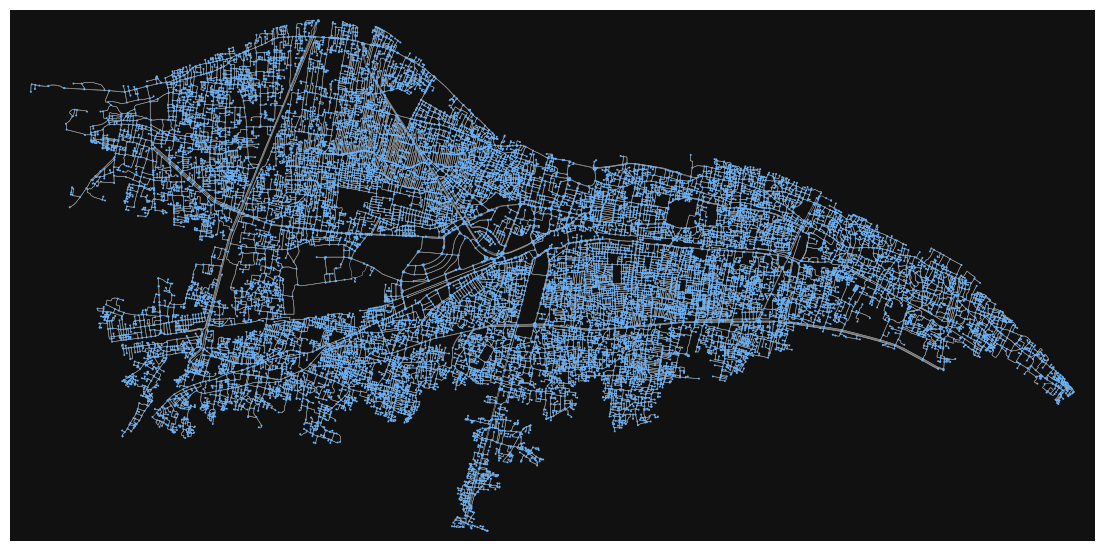

Text(0.5, 1.0, 'Patna Road Network (23,144 nodes)')

In [4]:
# -- Plot the road network -------------------------------
fig, ax = ox.plot_graph(
    G, figsize=(14, 14),
    node_size=2, node_color='#66b3ff',
    edge_color='#999999', edge_linewidth=0.4,
    bgcolor='#111111',
    show=True, close=False,
)
ax.set_title(f"Patna Road Network ({G.number_of_nodes():,} nodes)", color='white', fontsize=16)

In [5]:
# -- Save the graph for reuse (routing/graph_builder.py) -
import os
os.makedirs('../data', exist_ok=True)
ox.save_graphml(G, filepath='../data/patna_road_graph.graphml')
print("Graph saved at ../data/patna_road_graph.graphml")

Graph saved at ../data/patna_road_graph.graphml


## 2. Generate H3 Hexagonal Grid

We cover Patna's bounding box with H3 hexagons at **resolution 8**
(~460 m edge length). This is the spatial unit for all safety scoring.

Each hex cell will later store:
- `base_infra_score` (from the DNN)
- `poi_metadata` (feature counts)

In [6]:
# -- Extract bounding box from the graph -----------------
nodes = ox.graph_to_gdfs(G, edges=False)
north, south = nodes['y'].max(), nodes['y'].min()
east, west = nodes['x'].max(), nodes['x'].min()

print(f"Bounding Box:")
print(f"  North: {north:.4f}  South: {south:.4f}")
print(f"  East:  {east:.4f}   West:  {west:.4f}")

Bounding Box:
  North: 25.6510  South: 25.5399
  East:  85.2638   West:  85.0122


In [7]:
# -- Generate H3 cells covering the bounding box ---------
H3_RESOLUTION = 8

# Create a polygon from the bounding box
bbox_polygon = h3.LatLngPoly(
    [(north, west), (north, east), (south, east), (south, west)]
)

# Fill the polygon with H3 cells
hex_ids = list(h3.polygon_to_cells(bbox_polygon, H3_RESOLUTION))
print(f"H3 Resolution: {H3_RESOLUTION}")
print(f"Total hex cells covering Patna: {len(hex_ids):,}")

H3 Resolution: 8
Total hex cells covering Patna: 422


In [8]:
# -- Build a GeoDataFrame of hex cells -------------------
hex_data = []
for h in hex_ids:
    boundary = h3.cell_to_boundary(h)  # list of (lat, lng)
    centroid = h3.cell_to_latlng(h)
    # Shapely expects (lng, lat)
    poly = Polygon([(lng, lat) for lat, lng in boundary])
    hex_data.append({
        'hex_id': h,
        'centroid_lat': centroid[0],
        'centroid_lng': centroid[1],
        'geometry': poly,
    })

gdf_hex = gpd.GeoDataFrame(hex_data, crs='EPSG:4326')
print(f"Hex GeoDataFrame shape: {gdf_hex.shape}")
gdf_hex.head()

Hex GeoDataFrame shape: (422, 4)


,hex_id,centroid_lat,centroid_lng,geometry
0,883c138c51fffff,25.635425,85.074312,"POLYGON ((85.07889 25.63307, 85.07912 25.63787..."
1,883c13b985fffff,25.608367,85.260723,"POLYGON ((85.26531 25.60601, 85.26553 25.61081..."
2,883c138dcdfffff,25.577782,85.071630,"POLYGON ((85.07621 25.57543, 85.07643 25.58023..."
3,883c138db1fffff,25.549404,85.117196,"POLYGON ((85.12178 25.54705, 85.122 25.55185, ..."
4,883c13b825fffff,25.636863,85.224513,"POLYGON ((85.2291 25.6345, 85.22932 25.63931, ..."


In [9]:
# -- Visualise the H3 grid on a Folium map ---------------
center_lat = (north + south) / 2
center_lng = (east + west) / 2

m = folium.Map(location=[center_lat, center_lng], zoom_start=12, tiles='CartoDB dark_matter')

for _, row in gdf_hex.iterrows():
    # Convert polygon coords back to (lat, lng) for Folium
    coords = [(lat, lng) for lng, lat in row['geometry'].exterior.coords]
    folium.Polygon(
        locations=coords,
        color='#00d4ff',
        weight=0.5,
        fill=True,
        fill_color='#00d4ff',
        fill_opacity=0.08,
    ).add_to(m)

print(f"Map centered at ({center_lat:.4f}, {center_lng:.4f}) with {len(gdf_hex)} hexagons")
m

Map centered at (25.5954, 85.1380) with 422 hexagons


## 3. Query Infrastructure POIs

We use OSMnx's `features_from_place()` to query OpenStreetMap for
infrastructure relevant to safety scoring (DESIGN.md Â§2A):

| Feature Category | OSM Tags |
|-----------------|----------|
| Hospitals | `amenity=hospital`, `amenity=clinic` |
| Police Stations | `amenity=police` |
| Residential (Light Proxy) | `landuse=residential`, `building=apartments` |
| Commercial / Retail | `amenity=restaurant`, `amenity=fast_food`, `shop=True` |
| Hospitality | `tourism=hotel` |
| Fire Stations | `amenity=fire_station` |
| Schools | `amenity=school`, `amenity=college` |
| Banks / ATMs | `amenity=bank`, `amenity=atm` |
| Bus Stops | `highway=bus_stop`, `amenity=bus_station` |

In [10]:
# -- Define POI categories and their OSM tags ------------
POI_QUERIES = {
    'hospital':      {'amenity': ['hospital', 'clinic']},
    'police':        {'amenity': 'police'},
    'residential':   {'landuse': 'residential', 'building': 'apartments'},
    'commercial':    {'amenity': ['restaurant', 'fast_food', 'pub', 'bar'], 'shop': True},
    'hotel':         {'tourism': 'hotel'},
    'fire_station':  {'amenity': 'fire_station'},
    'school':        {'amenity': ['school', 'college', 'university']},
    'bank':          {'amenity': ['bank', 'atm']},
    'bus_stop':      {'highway': 'bus_stop', 'amenity': 'bus_station'}
}

poi_gdfs = {}

for category, tags in POI_QUERIES.items():
    try:
        gdf = ox.features_from_place(PLACE_NAME, tags=tags)
        poi_gdfs[category] = gdf
        print(f"  {category:15s} : {len(gdf):>5,} features")
    except Exception as e:
        poi_gdfs[category] = gpd.GeoDataFrame()  # Empty
        print(f"  {category:15s} : 0 features (query failed)")

print(f"\nTotal categories queried: {len(poi_gdfs)}")

  hospital        :   273 features


  police          :    19 features
  residential     :   148 features
  commercial      :   748 features
  hotel           :    34 features
  fire_station    : 0 features (query failed)
  school          :    93 features
  bank            :   156 features
  bus_stop        :    11 features

Total categories queried: 9


## 4. Map POIs to H3 Cells: Feature Matrix

For each H3 cell, we count the number of POIs from each category
that fall within the cell boundary. This creates the feature vector
used as input to the SafetyNet DNN (DESIGN.md Â§2A).

In [11]:
# -- Helper: get the representative point for a POI ------
def get_poi_point(geom):
    """Extract a point from any geometry type."""
    if geom.geom_type == 'Point':
        return geom
    else:
        return geom.centroid


# -- Count POIs per H3 cell ------------------------------
# Initialise feature columns
for cat in POI_QUERIES.keys():
    gdf_hex[f'count_{cat}'] = 0

for category, gdf_poi in poi_gdfs.items():
    if gdf_poi.empty:
        continue
    
    col = f'count_{category}'
    
    for idx, poi_row in gdf_poi.iterrows():
        try:
            pt = get_poi_point(poi_row.geometry)
            # Map point to H3 cell
            cell = h3.latlng_to_cell(pt.y, pt.x, H3_RESOLUTION)
            # Increment count if cell is in our grid
            mask = gdf_hex['hex_id'] == cell
            if mask.any():
                gdf_hex.loc[mask, col] += 1
        except Exception:
            continue

# Show summary
feature_cols = [c for c in gdf_hex.columns if c.startswith('count_')]
print("POI counts per cell (summary):")
print(gdf_hex[feature_cols].describe().round(2))

POI counts per cell (summary):
       count_hospital  count_police  count_residential  count_commercial  \
count          422.00        422.00             422.00            422.00   
mean             0.65          0.05               0.35              1.77   
std              1.90          0.26               2.55              6.84   
min              0.00          0.00               0.00              0.00   
25%              0.00          0.00               0.00              0.00   
50%              0.00          0.00               0.00              0.00   
75%              0.00          0.00               0.00              0.00   
max             13.00          3.00              47.00             68.00   

       count_hotel  count_fire_station  count_school  count_bank  \
count       422.00               422.0        422.00      422.00   
mean          0.08                 0.0          0.22        0.37   
std           0.44                 0.0          0.72        1.50   
min         

In [12]:
# -- Add intersection density per cell -------------------
# Count road network nodes (intersections) in each hex cell
gdf_hex['count_intersections'] = 0

for node_id, data in G.nodes(data=True):
    lat, lng = data['y'], data['x']
    cell = h3.latlng_to_cell(lat, lng, H3_RESOLUTION)
    mask = gdf_hex['hex_id'] == cell
    if mask.any():
        gdf_hex.loc[mask, 'count_intersections'] += 1

feature_cols.append('count_intersections')
print(f"Intersection density - mean: {gdf_hex['count_intersections'].mean():.1f}, max: {gdf_hex['count_intersections'].max()}")

Intersection density - mean: 54.8, max: 247


In [13]:
# -- Inspect the feature matrix --------------------------
all_features = [c for c in gdf_hex.columns if c.startswith('count_')]
print(f"\nFeature columns ({len(all_features)}):")
for f in all_features:
    total = gdf_hex[f].sum()
    nonzero = (gdf_hex[f] > 0).sum()
    print(f"  {f:25s} - total: {total:>6,}  |  cells with >=1: {nonzero:>5,} / {len(gdf_hex)}")

gdf_hex[['hex_id', 'centroid_lat', 'centroid_lng'] + all_features].head(10)


Feature columns (10):
  count_hospital            - total:    273  |  cells with >=1:    84 / 422
  count_police              - total:     19  |  cells with >=1:    15 / 422
  count_residential         - total:    147  |  cells with >=1:    40 / 422
  count_commercial          - total:    748  |  cells with >=1:    76 / 422
  count_hotel               - total:     34  |  cells with >=1:    21 / 422
  count_fire_station        - total:      0  |  cells with >=1:     0 / 422
  count_school              - total:     93  |  cells with >=1:    50 / 422
  count_bank                - total:    156  |  cells with >=1:    49 / 422
  count_bus_stop            - total:     11  |  cells with >=1:     8 / 422
  count_intersections       - total: 23,140  |  cells with >=1:   229 / 422


,hex_id,centroid_lat,centroid_lng,count_hospital,count_police,count_residential,count_commercial,count_hotel,count_fire_station,count_school,count_bank,count_bus_stop,count_intersections
0,883c138c51fffff,25.635425,85.074312,0,0,0,0,0,0,0,0,0,67
1,883c13b985fffff,25.608367,85.260723,0,0,0,0,0,0,0,0,0,0
2,883c138dcdfffff,25.577782,85.071630,1,0,0,0,0,0,0,0,0,142
3,883c138db1fffff,25.549404,85.117196,1,0,0,0,0,0,0,0,0,125
4,883c13b825fffff,25.636863,85.224513,0,0,0,0,0,0,0,0,0,0
5,883c138c6dfffff,25.606227,85.035448,0,0,0,0,0,0,0,0,0,5
6,883c138d2bfffff,25.548575,85.032774,0,0,0,0,0,0,0,0,0,0
7,883c131663fffff,25.556925,85.150377,0,0,0,0,0,0,0,0,0,0
8,883c138f11fffff,25.620538,85.026736,0,0,0,0,0,0,0,0,0,32
9,883c13b969fffff,25.614768,85.171851,0,0,0,0,0,0,0,0,0,140


## 5. Visualise Infrastructure Density

Create a heatmap-style Folium overlay showing total infrastructure
density per cell. Cells with more POIs appear in warmer colours.

In [14]:
# -- Compute total POI density per cell ------------------
gdf_hex['total_poi_count'] = gdf_hex[all_features].sum(axis=1)

# Normalise to [0, 1] for colour mapping
max_count = gdf_hex['total_poi_count'].max()
gdf_hex['density_norm'] = gdf_hex['total_poi_count'] / max_count if max_count > 0 else 0

print(f"Max total POIs in a single cell: {max_count}")
print(f"Cells with zero POIs: {(gdf_hex['total_poi_count'] == 0).sum()} / {len(gdf_hex)}")

Max total POIs in a single cell: 296
Cells with zero POIs: 192 / 422


In [15]:
# -- Folium heatmap of infrastructure density ------------
import branca.colormap as cm

colormap = cm.LinearColormap(
    colors=['#1a1a2e', '#16213e', '#e94560', '#ff6b6b', '#ffd93d'],
    vmin=0, vmax=1,
    caption='Infrastructure Density (normalised)'
)

m2 = folium.Map(location=[center_lat, center_lng], zoom_start=12, tiles='CartoDB dark_matter')

for _, row in gdf_hex.iterrows():
    coords = [(lat, lng) for lng, lat in row['geometry'].exterior.coords]
    density = row['density_norm']
    
    folium.Polygon(
        locations=coords,
        color=colormap(density),
        weight=0.5,
        fill=True,
        fill_color=colormap(density),
        fill_opacity=0.5 if density > 0 else 0.05,
        popup=f"Hex: {row['hex_id']}<br>POIs: {row['total_poi_count']}",
    ).add_to(m2)

colormap.add_to(m2)
print("Infrastructure density heatmap:")
m2

Infrastructure density heatmap:


## 6. Export Processed Data

Save the H3 grid with feature counts for use in:
- `notebooks/02_synthetic_data_gen.ipynb` (DNN training data)
- `data/crud/grid.py` (Supabase upload)

In [16]:
# -- Export to CSV (without geometry for portability) -----
export_cols = ['hex_id', 'centroid_lat', 'centroid_lng'] + all_features + ['total_poi_count', 'density_norm']
export_df = gdf_hex[export_cols].copy()

os.makedirs('../data', exist_ok=True)
export_path = '../data/patna_h3_grid_features.csv'
export_df.to_csv(export_path, index=False)
print(f"Exported {len(export_df):,} hex cells to {export_path}")
print(f"Feature dimensions: {len(all_features)} columns")
export_df.head()

Exported 422 hex cells to ../data/patna_h3_grid_features.csv
Feature dimensions: 10 columns


,hex_id,centroid_lat,centroid_lng,count_hospital,count_police,count_residential,count_commercial,count_hotel,count_fire_station,count_school,count_bank,count_bus_stop,count_intersections,total_poi_count,density_norm
0,883c138c51fffff,25.635425,85.074312,0,0,0,0,0,0,0,0,0,67,67,0.226351
1,883c13b985fffff,25.608367,85.260723,0,0,0,0,0,0,0,0,0,0,0,0.000000
2,883c138dcdfffff,25.577782,85.071630,1,0,0,0,0,0,0,0,0,142,143,0.483108
3,883c138db1fffff,25.549404,85.117196,1,0,0,0,0,0,0,0,0,125,126,0.425676
4,883c13b825fffff,25.636863,85.224513,0,0,0,0,0,0,0,0,0,0,0,0.000000


In [17]:
# -- Summary ---------------------------------------------
print("="*60)
print("  NOTEBOOK 01 - COMPLETE")
print("="*60)
print(f"  Road graph     : {G.number_of_nodes():>6,} nodes, {G.number_of_edges():>6,} edges")
print(f"  H3 grid        : {len(gdf_hex):>6,} cells (resolution {H3_RESOLUTION})")
print(f"  Feature columns: {len(all_features):>6}")
print(f"  Saved graph    : ../data/patna_road_graph.graphml")
print(f"  Saved features : {export_path}")
print("="*60)
print("\nNext step: notebooks/02_synthetic_data_gen.ipynb")

  NOTEBOOK 01 - COMPLETE
  Road graph     : 23,144 nodes, 55,926 edges
  H3 grid        :    422 cells (resolution 8)
  Feature columns:     10
  Saved graph    : ../data/patna_road_graph.graphml
  Saved features : ../data/patna_h3_grid_features.csv

Next step: notebooks/02_synthetic_data_gen.ipynb
